<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/Densidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
#1 Datos de Ejemplo (coordenadas de ciudades)
data = {
    "Ciudad": ["A", "B", "C", "D", "E", "F"],
    "x": [1.0, 1.5, 10.0, 1.1, 0.8, 1.4],
    "y": [1.0, 1.2, 10.0, 0.9, 1.3, 0.8],
    "poblacion": [500, 50, 10, 400, 300, 200] #Para contexto
}
df = pd.DataFrame(data)

In [3]:
#2 Preprocesamiento: Normalizar datos (opcional pero recomendado)
coords = df[["x", "y"]].values
coords_normalized = StandardScaler().fit_transform(coords) #Normaliza para evitar sesgos en escala

#3 Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=3) #Parametros Clave
clusters = dbscan.fit_predict(coords_normalized)

#4 Asignar clusters al DataFrame
df["cluster"] = clusters
print(df.head()) #Mostrar los primeros registros para verificar

  Ciudad     x     y  poblacion  cluster
0      A   1.0   1.0        500        0
1      B   1.5   1.2         50        0
2      C  10.0  10.0         10       -1
3      D   1.1   0.9        400        0
4      E   0.8   1.3        300        0


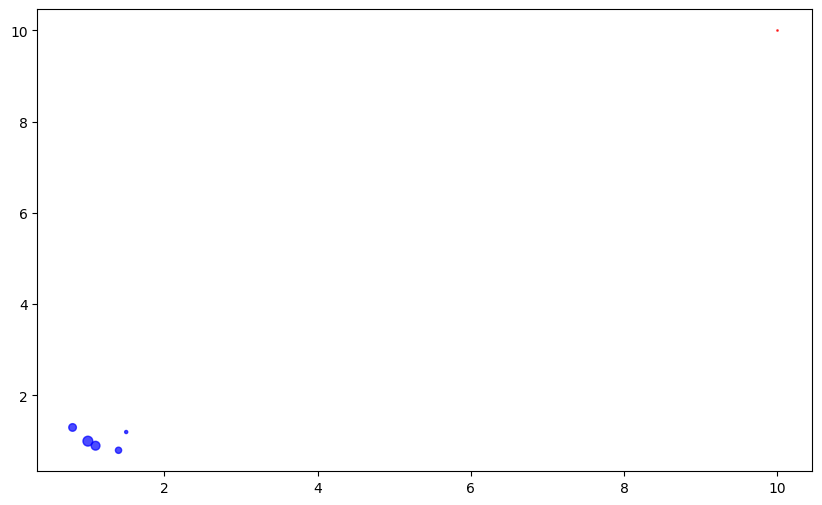

In [4]:
#Crea una figura con tamano personalizado
plt.figure(figsize=(10, 6))

#Definir colores para cada cluster (azul para cluster 0, rojo para ruido)
colors = {0: "blue", -1:"red"}

#Iterar sobre cada grupo de puntos segun su cluster
for cluster, group in df.groupby("cluster"):
  #Graficar los puntos:
  # -x: coordenada x original  (sin normalizar)
  # -y: coordenada y original
  # -color: segun el cluster
  # -tamano(s): proporcional a la poblacion (dividido entre 10 para ajustar)
  # -alpha: transparencia: (0.7 = 70% opaco)
  plt.scatter(
      group["x"], group["y"],
      color=colors[cluster],
      label=f"Cluster {cluster}" if cluster != -1 else "Ruido",
      s=group["poblacion"] / 10,
      alpha=0.7
  )

/tmp/ipykernel_1239/2876437920.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() #Mostrar leyenda (cluster y ruido)


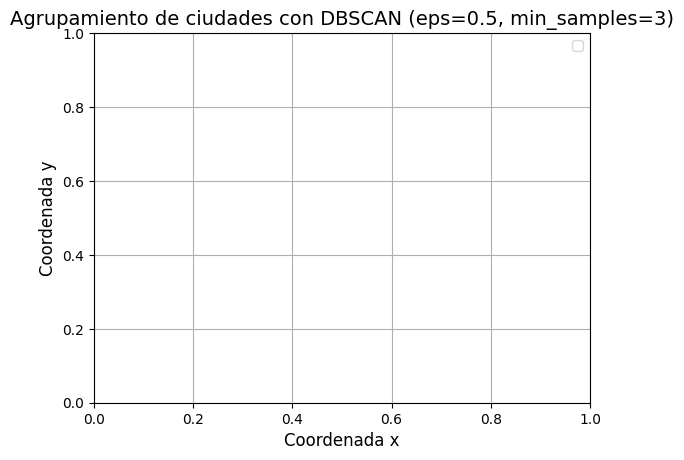


 Resultados de Clustering:
  Ciudad     x     y  cluster
0      A   1.0   1.0        0
1      B   1.5   1.2        0
2      C  10.0  10.0       -1
3      D   1.1   0.9        0
4      E   0.8   1.3        0
5      F   1.4   0.8        0


In [5]:
#Personalizar el grafico
plt.title("Agrupamiento de ciudades con DBSCAN (eps=0.5, min_samples=3)", fontsize=14)
plt.xlabel("Coordenada x", fontsize=12)
plt.ylabel("Coordenada y", fontsize=12)
plt.legend() #Mostrar leyenda (cluster y ruido)
plt.grid(True) #Anadir cuadricula
plt.show() #Mostrar el grafico

#4Resultado en linea
print("\n Resultados de Clustering:")
print(df[["Ciudad", "x", "y", "cluster"]])